# Obstacle-sweep IC generation

Generates the parameter sweeps used to build the weakly-compressible dam-break
dataset (and, for the collision family, a separate case entirely), and
previews the initial conditions before committing to a full run.

Structure:

1. **Setup** -- boilerplate imports.
2. **Shared sweep helpers** -- thin wrappers around `warpSPH.runner`, shared
   with `sweep_browser.ipynb` (both live in `utils.py` so the two notebooks
   render a config identically).
3. **One section per case family** -- define the matrix of parameter
   combinations, preview a sample of it inline, write the full sweep to
   `sweeps/<family>/*.json` plus a `cases/<family>.sh` runner.
4. **Diagnostics** -- a single full run with the live plotter, and a
   resolution convergence check. Not part of dataset generation; skip unless
   debugging.

Sweep configs are plain `CaseSpec` JSON (`warpSPH.runner.CaseSpec`), not shell
flag strings -- `python generator.py --config sweeps/<family>/<file>.json`
runs any of them directly, and `sweep_browser.ipynb` browses them
interactively instead of scrolling through saved PNGs.

In [1]:
%matplotlib widget
# Boilerplate import code for all libraries
# Changes to the precision require re-loading the kernel and need to be done before any op uses them.
import warpSPHCore_config as swc
from typing import Any
swc.configure(precision="float32", dim=Any) # precision: float16|half|float32|single|float64|double

import warpSPHCore as sph
from warpSPHCore.type_config import *
print(get_type_config()) # confirms active settings

# Initialize warp at this point
import warp as wp; wp.init()

import os
import torch
if torch.cuda.is_available(): # set the TORCH_CUDA_ARCH_LIST environment variable to the compute capability of the GPU for faster compiles
    os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)
from tqdm.autonotebook import tqdm

# final import blocks that are generic
import matplotlib.pyplot as plt
import numpy as np

# custom SPH libraries
from warpSPHIntegrators.integration import *
from warpSPHCore import *
from warpSPHPlotting import *

# This library
from warpSPH import *
from warpSPH.runner import run

# The case utilities that contain all the case setup functions for the various test cases
from warpSPH.caseUtils import *

{'scalar_t': <class 'warp._src.types.float32'>, 'dim_t': typing.Any}
Warp 1.16.0 initialized:
   CUDA Toolkit 12.9, Driver 13.3
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 6000 Blackwell Workstation Edition" (95 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.16.0


## Shared sweep helpers

`utils.py` (this directory) wraps `warpSPH.runner` with the handful of
functions this notebook and `sweep_browser.ipynb` both need:

- `baseSpecFor(case, **overrides)` -- a `CaseSpec` seeded from a `Case`'s own
  defaults/params (`FAMILY_CASE['dambreak']` is `warpSPH.cases.dambreak.dambreakCase`,
  `FAMILY_CASE['impact']` is `warpSPH.cases.impact.impactCase`).
- `buildMatrixSpecs(baseSpec, axes)` -- the cartesian product of an
  `{name: [values]}` dict as `(label, CaseSpec)` pairs.
- `previewMatrix(case, baseSpec, axes)` / `previewSample(case, specs, n=12)`
  -- render a matrix (or a sample of an already-built spec list) as one grid,
  by actually sampling each config's particles (`buildContext` ->
  `configureScheme` -> `buildSystem`, the same two hooks a real run calls
  first) -- never a hand-rolled SDF plot that can drift from what a run
  actually samples.
- `writeSweep(family, specs)` -- `sweeps/<family>/*.json` + an `index.json`
  of which params actually vary (read by `sweep_browser.ipynb`) +
  `cases/<family>.sh`.

The obstacle-shape library (`warpSPH.caseUtils.buildPresetObstacles`) and the
free-body shape library (`warpSPH.cases.weaklyCompressible.SHAPE_PRESETS`,
used by the collision family below) are worth listing once up front --
several of these were implemented but never swept by any case in this
notebook before.

In [2]:
from utils import (FAMILY_CASE, baseSpecFor, buildMatrixSpecs, previewMatrix,
                   previewSample, writeSweep, loadSweepIndex)
from warpSPH.caseUtils import buildPresetObstacles
from warpSPH.cases.weaklyCompressible import SHAPE_PRESETS

dambreakCase = FAMILY_CASE['dambreak']
impactCase = FAMILY_CASE['impact']

print('obstacle presets (dam-break family):', sorted(buildPresetObstacles(1, 0, 1, 1, 0)))
print()
print('free-body shapes (collision family):', sorted(SHAPE_PRESETS))

obstacle presets (dam-break family): ['circleBottom', 'circleMiddle', 'circleTop', 'ellipsoidBottom', 'ellipsoidMiddle', 'ellipsoidTop', 'equilateralBottom', 'equilateralMiddle', 'equilateralTop', 'hexagonBottom', 'hexagonMiddle', 'hexagonTop', 'horseshoeMiddle', 'roundedBoxBottom', 'roundedBoxMiddle', 'roundedBoxTop', 'squareBottom', 'squareMiddle', 'squareTop', 'starBottom', 'starMiddle', 'starTop', 'triangleBottom', 'triangleMiddle', 'triangleTop', 'wallBottom', 'wallMiddle', 'wallTop']

free-body shapes (collision family): ['box', 'circle', 'cutDisk', 'equilateralTriangle', 'hexagon', 'hexagram', 'moon', 'octogon', 'parallelogram', 'pentagon', 'rhombus', 'roundedBox', 'star5', 'trapezoid', 'triangleIsosceles', 'unevenCapsule', 'vesica']


## Dam break + obstacle

The main dataset family: a column of fluid released onto the floor of a
`W x L` tank, with an optional obstacle. `obstacleType` combines a shape with
a floor/mid/ceiling placement (`*Bottom`/`*Middle`/`*Top`); the four shapes
`roundedBox`/`hexagon`/`star`/`horseshoe` have SDFs in `buildObstacleSDF` but
had no preset entry and so were never exercised by any sweep -- they're
included below alongside the original six.

`fillRatio`/`fluidWidth` are paired (a fixed set of column proportions), so
that axis is a Python loop around the matrix rather than a `buildMatrixSpecs`
axis.

84 dambreak configs


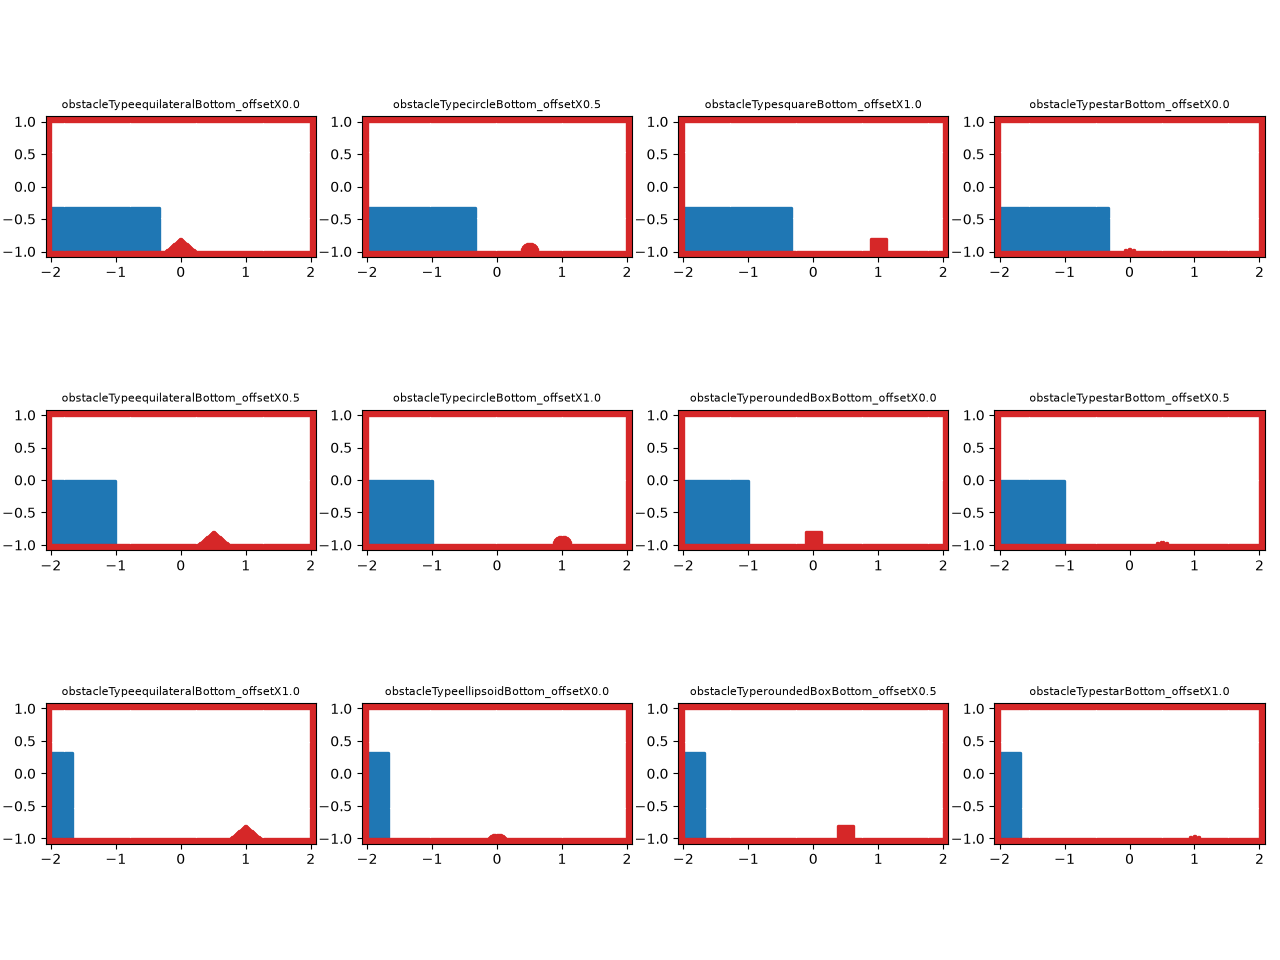

In [19]:
nx, targetDt = 128, 0.0005

obstacleShapesBMT = ['equilateral', 'triangle', 'circle', 'ellipsoid', 'square', 'roundedBox', 'hexagon', 'star']
obstacleTypesBottom = [f'{s}Bottom' for s in obstacleShapesBMT] + ['wallBottom']

# (fillRatio, fluidWidth) pairs -- a 1/3, 1/2 and 2/3-full tank, each with a
# column proportioned to give roughly the same total fluid volume.
dambreakGeometry = [(1/3, 5/12), (1/2, 1/4), (2/3, 1/12)]

dambreakAxes = {
    'obstacleType': obstacleTypesBottom,
    'offsetX': [0.0, 0.5, 1.0],
    'maxExtent': [0.25],
    'aoa': [0.0],
}

dambreakSpecs = []
for fillRatio, fluidWidth in dambreakGeometry:
    base = baseSpecFor(dambreakCase, nx=nx, tLimit=6.0,
                       params=dict(W=4.0, fillRatio=fillRatio, fluidWidth=fluidWidth,
                                  targetDt=targetDt, obstacleActive=True))
    dambreakSpecs += buildMatrixSpecs(base, dambreakAxes)

# A no-obstacle baseline at each fill ratio, for comparison.
for fillRatio, fluidWidth in dambreakGeometry:
    base = baseSpecFor(dambreakCase, nx=nx, tLimit=6.0,
                       params=dict(W=4.0, fillRatio=fillRatio, fluidWidth=fluidWidth,
                                  targetDt=targetDt, obstacleActive=False))
    dambreakSpecs.append((f'noObstacle_fillRatio{fillRatio:.3g}', base))

print(f'{len(dambreakSpecs)} dambreak configs')
previewSample(dambreakCase, dambreakSpecs, n=12, ncols=4);

In [20]:
writeSweep('dambreak', dambreakSpecs)

'sweeps/dambreak'

## Fully periodic

Same obstacle library, submerged mid-depth (`*Middle`) in a periodic box with
no free surface at the side walls, plus an `aspectRatio` axis -- no matrix in
the old notebook ever varied aspect ratio, even though every obstacle preset
already accepts one (it squashes the shape along its second axis, so it's
meaningful for every shape here, not just the box/ellipse ones).

90 fullyPeriodic configs


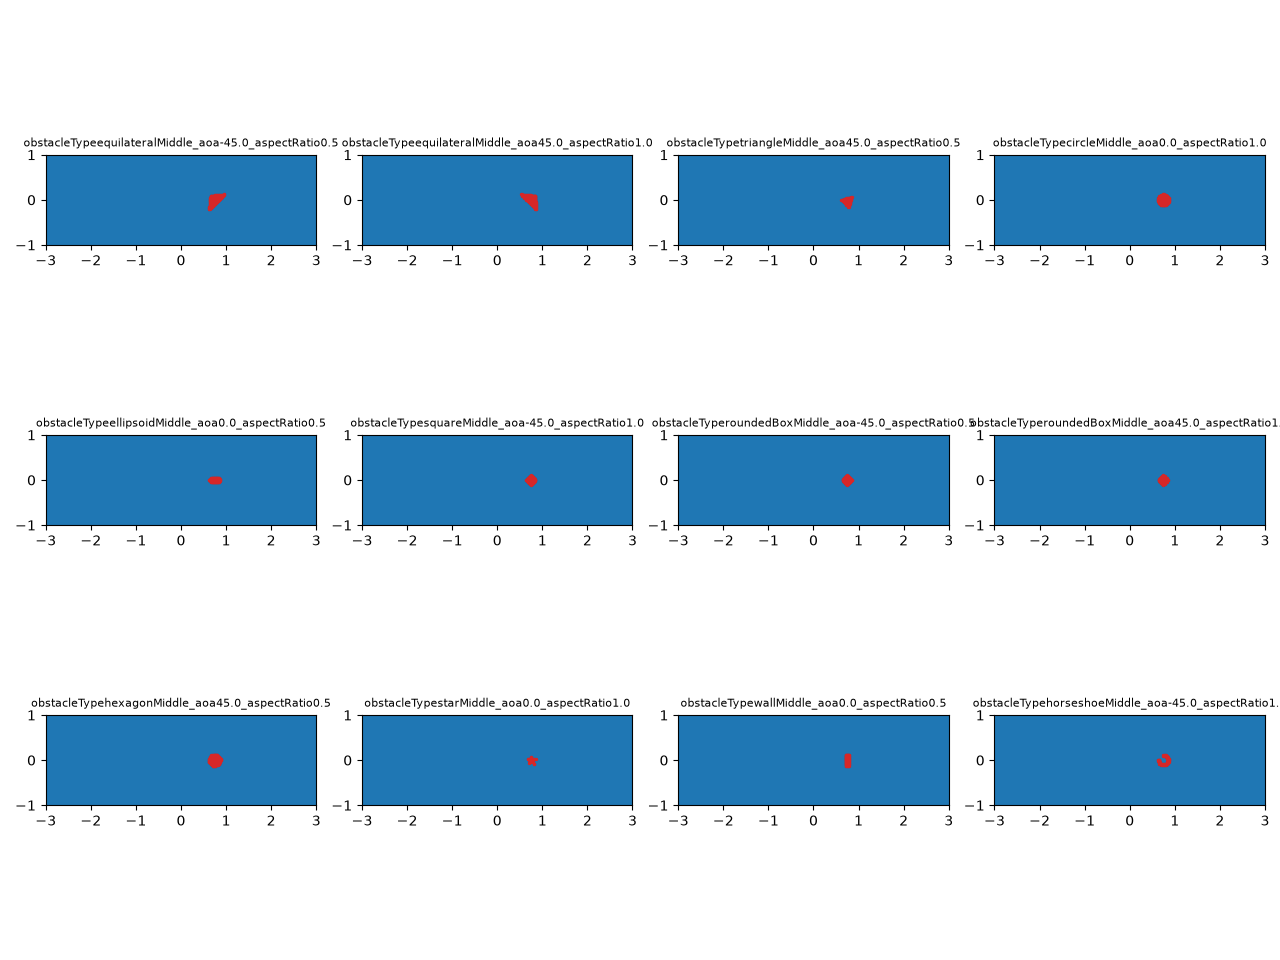

In [21]:
obstacleTypesMiddle = [f'{s}Middle' for s in obstacleShapesBMT] + ['wallMiddle', 'horseshoeMiddle']

fullyPeriodicAxes = {
    'obstacleType': obstacleTypesMiddle,
    'aoa': [-45.0, 0.0, 45.0],
    'aspectRatio': [0.5, 1.0, 2.0],
    'maxExtent': [0.25],
}
fullyPeriodicBase = baseSpecFor(dambreakCase, nx=nx, tLimit=8.0,
                                params=dict(W=6.0, fillRatio=1.0, fluidWidth=1.0,
                                           targetDt=targetDt, obstacleActive=True,
                                           disableGravity=True, fullyPeriodic=True,
                                           enableFreestream=True, freeStreamVelocity=1.0))
fullyPeriodicSpecs = buildMatrixSpecs(fullyPeriodicBase, fullyPeriodicAxes)
print(f'{len(fullyPeriodicSpecs)} fullyPeriodic configs')
previewSample(dambreakCase, fullyPeriodicSpecs, n=12, ncols=4);

In [22]:
writeSweep('fullyPeriodic', fullyPeriodicSpecs)

'sweeps/fullyPeriodic'

## Semi-periodic

Periodic in `x`, walled in `y`. Same obstacle/aoa matrix, with a
`freeStreamVelocity` axis added for Reynolds-number variety without any new
geometry (the old sweep cells all hardcoded it to `1.0`).

90 semiPeriodic configs


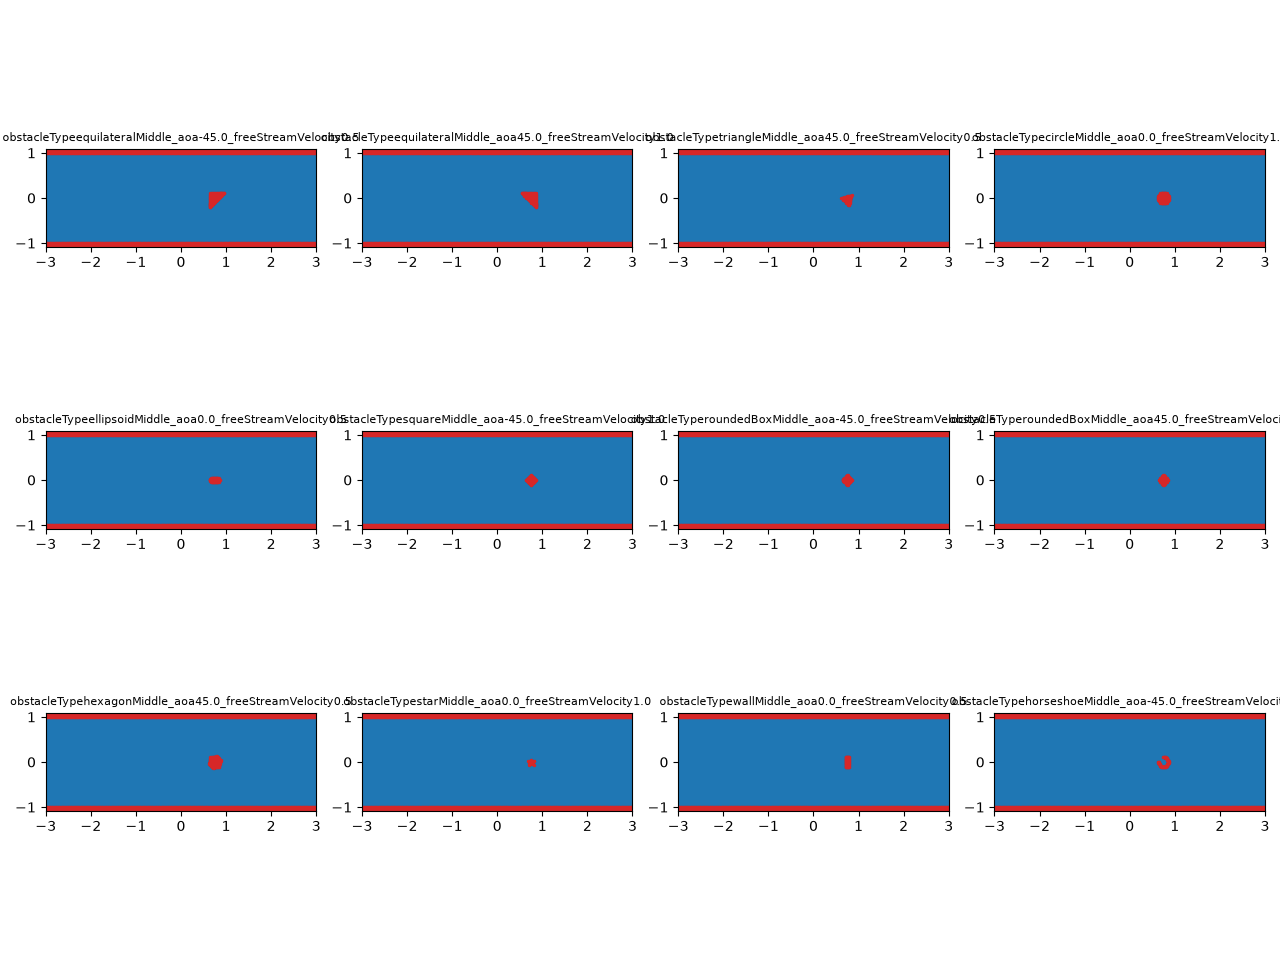

In [23]:
semiPeriodicAxes = {
    'obstacleType': obstacleTypesMiddle,
    'aoa': [-45.0, 0.0, 45.0],
    'maxExtent': [0.25],
    'freeStreamVelocity': [0.5, 1.0, 2.0],
}
semiPeriodicBase = baseSpecFor(dambreakCase, nx=nx, tLimit=8.0,
                               params=dict(W=6.0, fillRatio=1.0, fluidWidth=1.0,
                                          targetDt=targetDt, obstacleActive=True,
                                          semiPeriodic=True, enableFreestream=True))
semiPeriodicSpecs = buildMatrixSpecs(semiPeriodicBase, semiPeriodicAxes)
print(f'{len(semiPeriodicSpecs)} semiPeriodic configs')
previewSample(dambreakCase, semiPeriodicSpecs, n=12, ncols=4);

In [24]:
writeSweep('semiPeriodic', semiPeriodicSpecs)

'sweeps/semiPeriodic'

## Open channel

Semi-periodic with a shallow fill ratio (an open channel rather than a full
tank) -- the broadest matrix, obstacle at all three placements.

252 openChannel configs


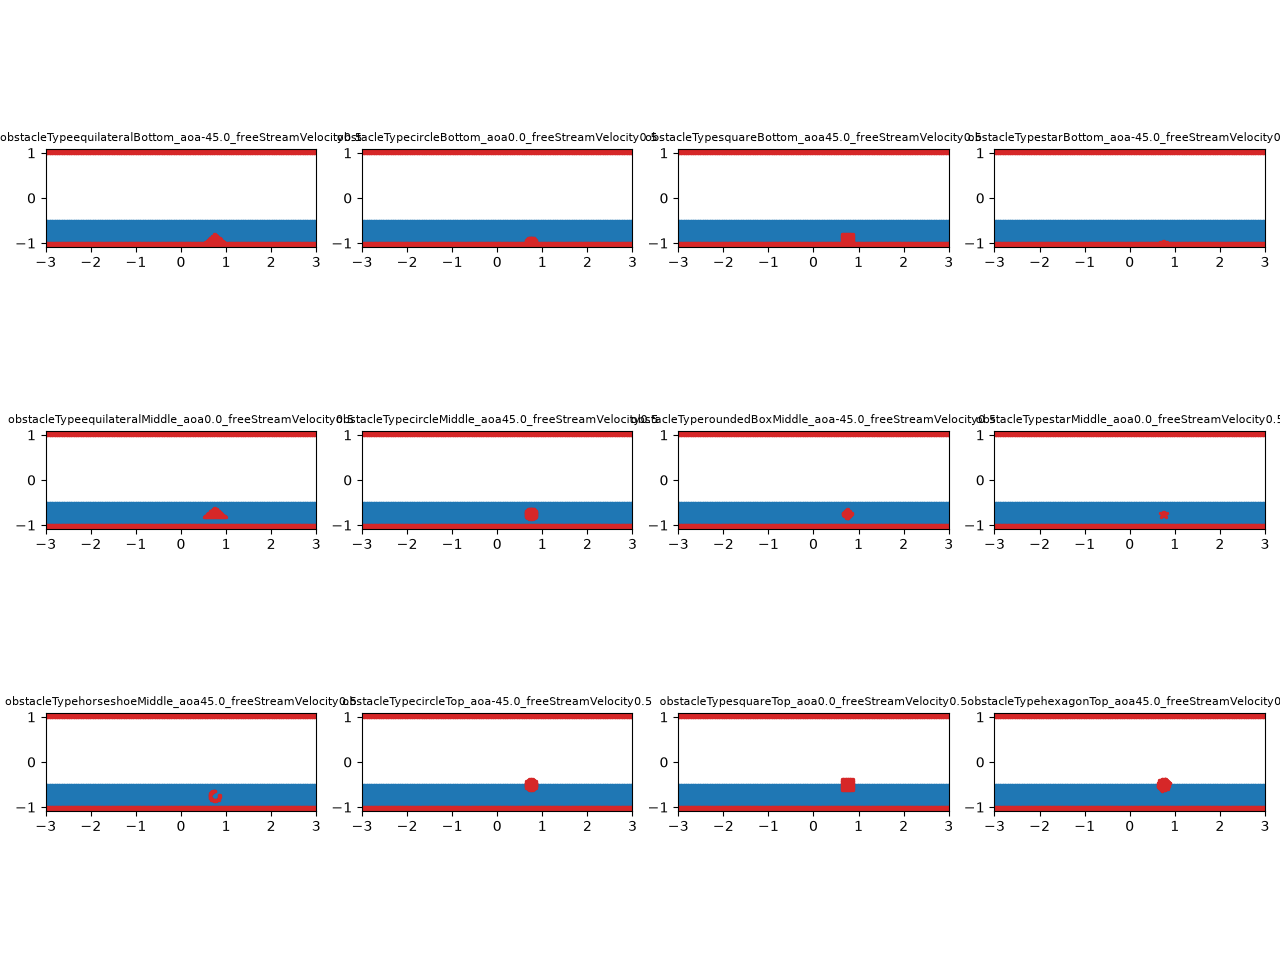

In [25]:
obstacleTypesTop = [f'{s}Top' for s in obstacleShapesBMT] + ['wallTop']
obstacleTypesAll = obstacleTypesBottom + obstacleTypesMiddle + obstacleTypesTop

openChannelAxes = {
    'obstacleType': obstacleTypesAll,
    'aoa': [-45.0, 0.0, 45.0],
    'maxExtent': [0.25],
    'freeStreamVelocity': [0.5, 1.0, 2.0],
}
openChannelBase = baseSpecFor(dambreakCase, nx=nx, tLimit=8.0,
                              params=dict(W=6.0, fillRatio=0.25, fluidWidth=1.0,
                                         targetDt=targetDt, obstacleActive=True,
                                         semiPeriodic=True, enableFreestream=True))
openChannelSpecs = buildMatrixSpecs(openChannelBase, openChannelAxes)
print(f'{len(openChannelSpecs)} openChannel configs')
previewSample(dambreakCase, openChannelSpecs, n=12, ncols=4);

In [26]:
writeSweep('openChannel', openChannelSpecs)

'sweeps/openChannel'

## Periodic flow with divergence-free noise, and Kolmogorov forcing

Both seed the dam break's `circleMiddle` obstacle setup with divergence-free
noise (`enableNoise`) in a periodic or bounded box; the Kolmogorov family
additionally drives a sinusoidal body force (`enableKolmogorovForcing`). These
are dam-break-family runs with noise/forcing layered on top -- distinct from
the dedicated `warpSPH.cases.randomFlow`/`kolmogorov` cases, which are pure
periodic flows with no free surface or tank geometry at all.

Seeds are drawn once, from a local `Generator`, so this cell is reproducible
across kernel restarts.

96 periodicNoise configs


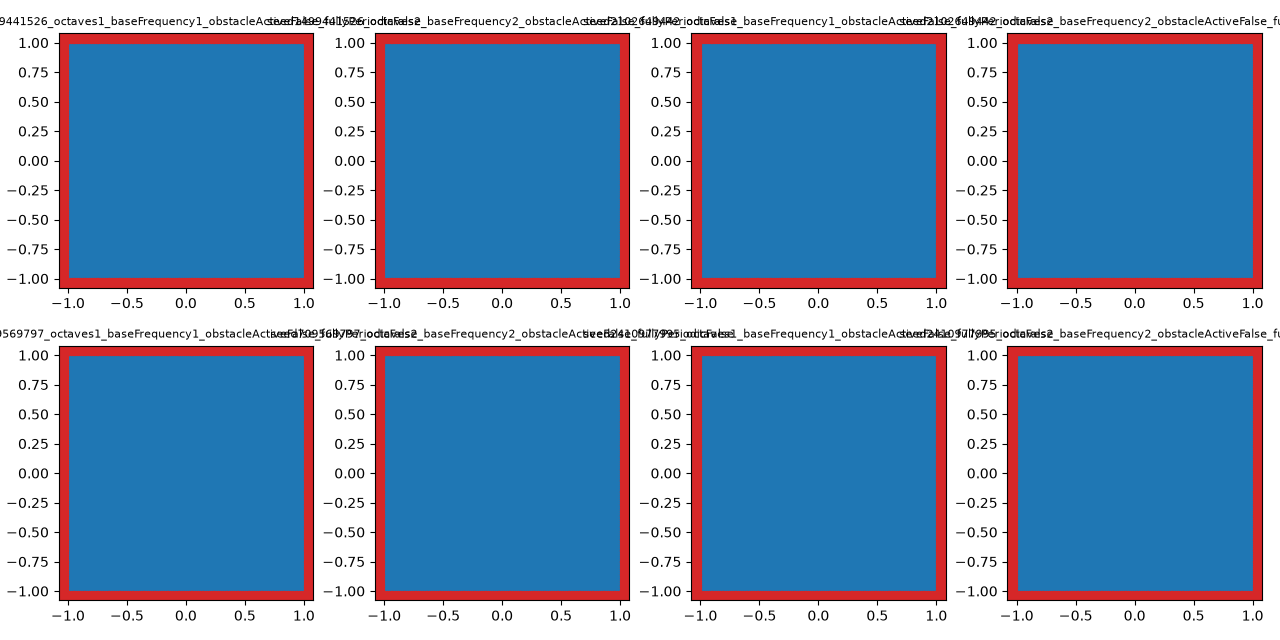

In [27]:
rng = np.random.default_rng(2187561599)
noiseSeeds = [int(s) for s in rng.integers(0, 2**32 - 1, size=4)]

periodicNoiseAxes = {
    'seed': noiseSeeds,
    'octaves': [1, 2, 4],
    'baseFrequency': [1, 2],
    'obstacleActive': [False, True],
    'fullyPeriodic': [False, True],
}
periodicNoiseBase = baseSpecFor(dambreakCase, nx=nx, tLimit=6.0,
                                params=dict(W=2.0, fillRatio=1.0, fluidWidth=1.0,
                                           targetDt=targetDt, disableGravity=True,
                                           obstacleType='circleMiddle', maxExtent=0.5,
                                           enableNoise=True, noiseAmplitude=1.0))
periodicNoiseSpecs = buildMatrixSpecs(periodicNoiseBase, periodicNoiseAxes)
print(f'{len(periodicNoiseSpecs)} periodicNoise configs')
previewSample(dambreakCase, periodicNoiseSpecs, n=8, ncols=4);

In [28]:
writeSweep('periodicNoise', periodicNoiseSpecs)

'sweeps/periodicNoise'

192 kolmogorov configs


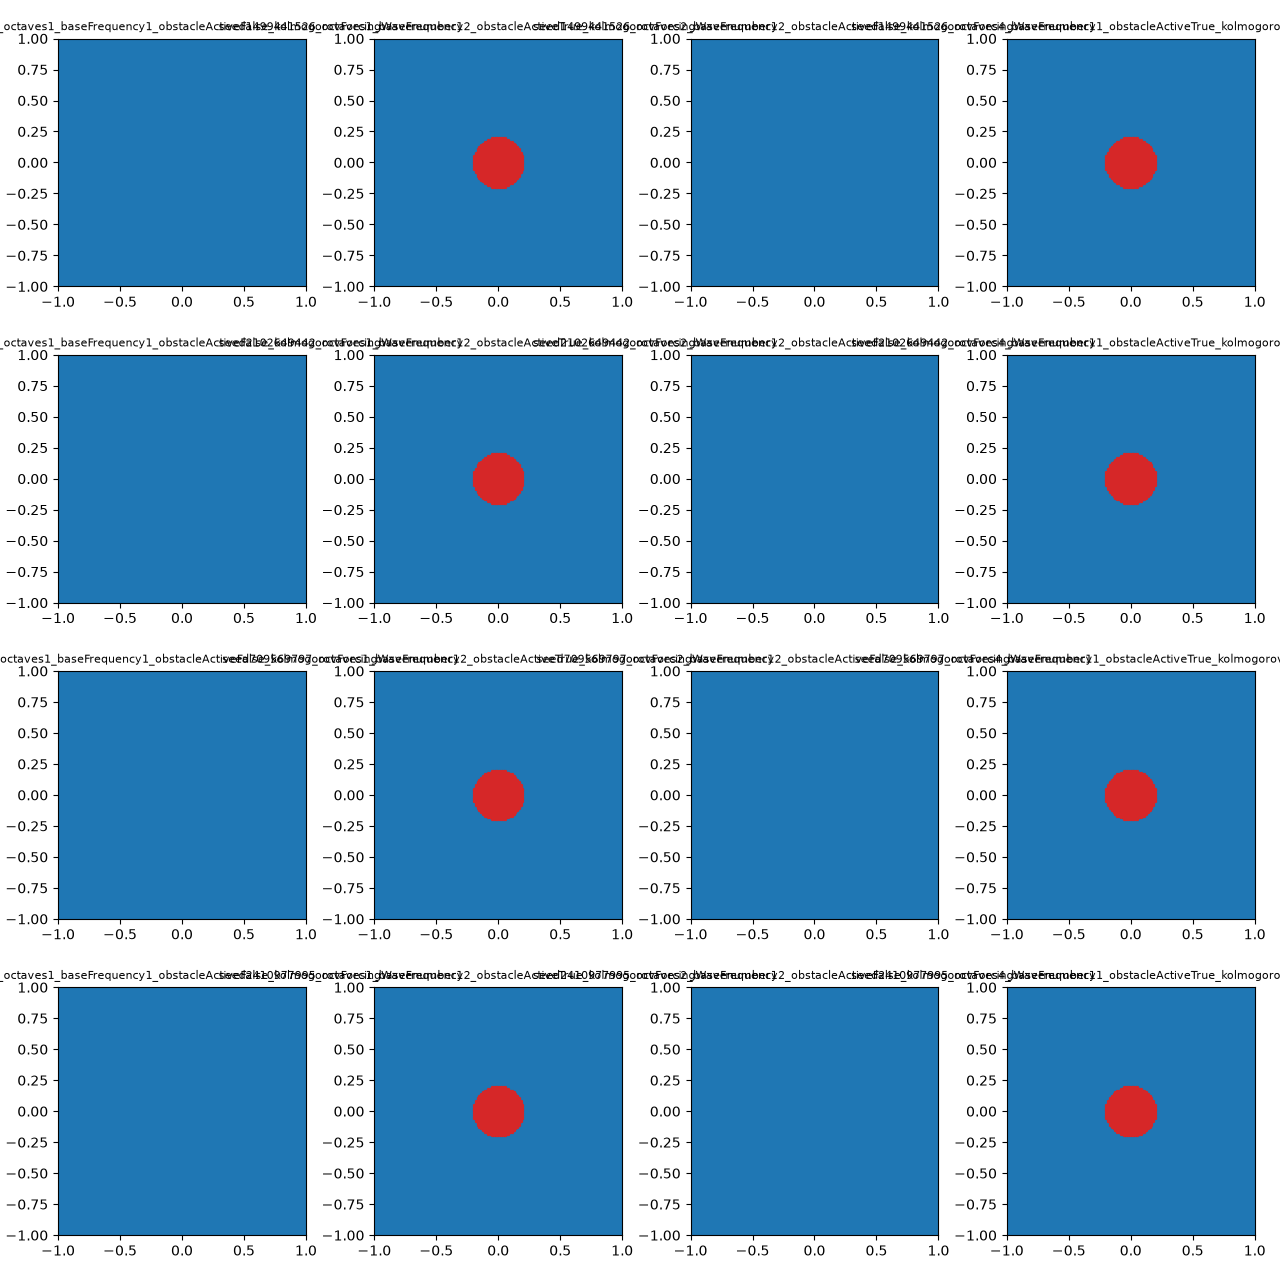

In [29]:
kolmogorovAxes = {
    'seed': noiseSeeds,
    'octaves': [1, 2, 4],
    'baseFrequency': [1, 2],
    'obstacleActive': [False, True],
    'kolmogorovForcingWavenumber': [1, 2, 4, 8],
    'offsetX': [0.0]
}
kolmogorovBase = baseSpecFor(dambreakCase, nx=nx, tLimit=8.0,
                             params=dict(W=2.0, fillRatio=1.0, fluidWidth=1.0,
                                        targetDt=targetDt, disableGravity=True,
                                        obstacleType='circleMiddle', maxExtent=0.4,
                                        fullyPeriodic=True, enableNoise=True,
                                        noiseAmplitude=0.1, enableKolmogorovForcing=True))
kolmogorovSpecs = buildMatrixSpecs(kolmogorovBase, kolmogorovAxes)
print(f'{len(kolmogorovSpecs)} kolmogorov configs')
previewSample(dambreakCase, kolmogorovSpecs, n=16, ncols=4);

In [30]:
writeSweep('kolmogorov', kolmogorovSpecs)

'sweeps/kolmogorov'

## Collision (impact)

Two or N free-surface bodies given equal-and-opposite velocities, no rigid
obstacle -- `warpSPH.cases.impact.impactCase`. Implemented and registered
already, but never wired into a datagen sweep. This is the "collision" case;
deliberately not `movingObstacleCase` (a spinning rigid obstacle), which is
out of scope for this dataset for now.

Two arrangements need different axes (`lateralOffset` only makes sense for a
`pair`, `nBodies` only for a `ring`), so -- like the paired `fillRatio`/
`fluidWidth` above -- they're two `buildMatrixSpecs` calls concatenated
rather than one matrix with unused axis combinations.

36 pair + 18 ring = 54 impact configs


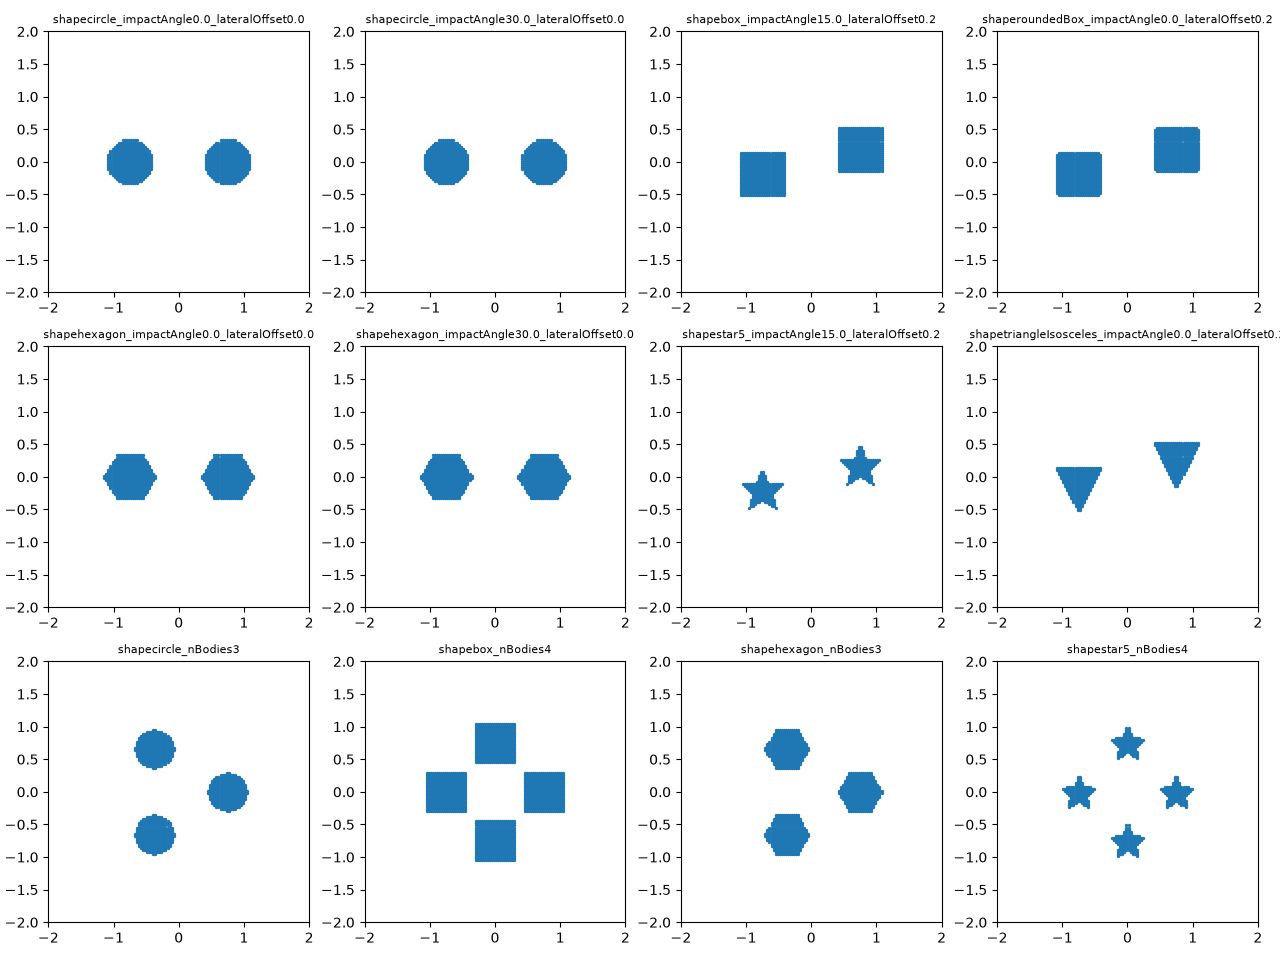

In [ ]:
impactShapes = ['circle', 'box', 'roundedBox', 'hexagon', 'star5', 'triangleIsosceles']

pairAxes = {
    'shape': impactShapes,
    # 0 = head-on, then increasingly oblique.
    'impactAngle': [0.0, 15.0, 30.0],
    'lateralOffset': [0.0, 0.2],
}
pairBase = baseSpecFor(impactCase, nx=nx, tLimit=3.0,
                       params=dict(arrangement='pair', size=0.35, impactVelocity=0.5))
pairSpecs = buildMatrixSpecs(pairBase, pairAxes)

ringAxes = {
    'shape': impactShapes,
    'nBodies': [3, 4, 5],
}
ringBase = baseSpecFor(impactCase, nx=nx, tLimit=3.0,
                       params=dict(arrangement='ring', size=0.3, impactVelocity=0.5))
ringSpecs = buildMatrixSpecs(ringBase, ringAxes)

impactSpecs = pairSpecs + ringSpecs
print(f'{len(pairSpecs)} pair + {len(ringSpecs)} ring = {len(impactSpecs)} impact configs')
previewSample(impactCase, impactSpecs, n=12, ncols=4);

In [32]:
writeSweep('impact', impactSpecs)

'sweeps/impact'

## Diagnostics -- single-run sanity check

Not dataset generation: a full run of one config with the live plotter, to
sanity-check that a sweep entry actually behaves before generating the whole
family from it. `warpSPH.runner.run` is the same function `generator.py`
calls -- this is not a second, hand-rolled step loop.

In [ ]:
diagSpec = baseSpecFor(dambreakCase, nx=128, tLimit=6.0,
                       params=dict(W=4.0, fillRatio=1/3, fluidWidth=5/12,
                                  obstacleActive=True, obstacleType='hexagonMiddle',
                                  maxExtent=0.2, offsetX=0.75))
diagSpec = diagSpec.merged(plot=True, show=True, holdPlot=True, store=False,
                           plotBackend='vispy', plotInterval=20)

diagResult = run(dambreakCase, diagSpec)
print('diverged:', diagResult.diverged, '| steps:', diagResult.nSteps)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(diagResult.series('t'), diagResult.series('maxVelocity'))
axes[0].set_xlabel('t'); axes[0].set_ylabel('max fluid velocity')
axes[1].plot(diagResult.series('t'), diagResult.series('kineticEnergy'))
axes[1].set_xlabel('t'); axes[1].set_ylabel('kinetic energy')
fig.tight_layout()

## Diagnostics -- resolution convergence

`dambreakCase` doesn't expose a viscosity parameter (the old notebook's
`nu_visc` was set but never actually wired into the scheme config, so its
"convergence test" wasn't testing what it looked like it was testing) --
`nx` is the axis that's actually meaningful to sweep here.

In [ ]:
resolutions = [32, 64, 96, 128]
convergence = []
for res in resolutions:
    spec = baseSpecFor(dambreakCase, nx=res, tLimit=1.0,
                       params=dict(W=4.0, fillRatio=1/3, fluidWidth=5/12, obstacleActive=False))
    spec = spec.merged(plot=False, store=False, quiet=True)
    result = run(dambreakCase, spec)
    convergence.append((res, result.series('maxVelocity')[-1], result.series('kineticEnergy')[-1]))
    print(f'nx={res}: maxVelocity={convergence[-1][1]:.4g}, KE={convergence[-1][2]:.4g}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot([r[0] for r in convergence], [r[1] for r in convergence], marker='o')
axes[0].set_xlabel('nx'); axes[0].set_ylabel('max velocity at t=1.0')
axes[1].plot([r[0] for r in convergence], [r[2] for r in convergence], marker='o')
axes[1].set_xlabel('nx'); axes[1].set_ylabel('kinetic energy at t=1.0')
fig.tight_layout()